idea no. 1: try to predict intensity curve, or may be classify materials by intensity category. As a first step we are going to try Wakayama experimental data set (see ref 1).

references:

1. https://pubs.acs.org/doi/abs/10.1021/acs.iecr.9b01225#
2. https://pmc.ncbi.nlm.nih.gov/articles/PMC12363845/

Transport related features of molecules MW, MLOGP, vapor preassure, boiling point, alpha area, 
and five descriptors most correlated with Hill coefficients (CATS2D_03_LL, SpMax8_Bh.p., MPC07, MATS7i, H2s).

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_utils import get_waka_df, get_dragon_df

In [3]:
# Creation of dataframes
waka_df = get_waka_df()

Fetching Pubchem CIDs (this may take time)
🔍 Missing CID count: 2 out of 314 rows
Rows with missing CID were deleted


In [4]:
waka_df.to_csv('data/waka_with_CID.csv')

In [5]:
waka_df = pd.read_csv('data/waka_with_CID.csv')

In [8]:
# Understand the distribution of intensities in the data set
vIntensities = waka_df['Imax'].values
vIntensities.shape

(312,)

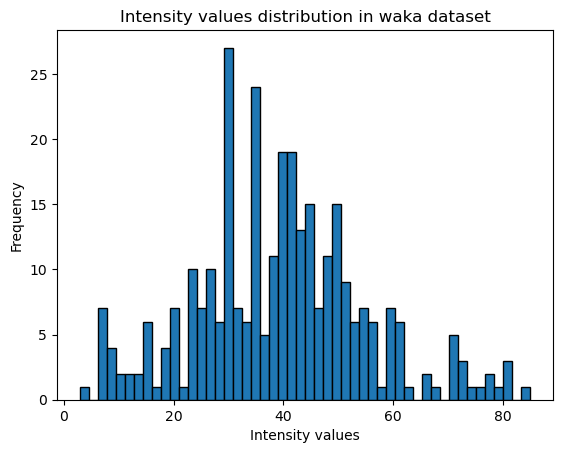

In [ ]:
plt.hist(vIntensities, bins=50, edgecolor = 'black')
plt.xlabel('Intensity values')
plt.ylabel('Frequency')
plt.title('Intensity values distribution in Waka dataset')
plt.show()

In [ ]:
# For prctice of binary classification i want to devide my data set for intense materials and not intense material 
# I set the threshold to 35, so intense >= 35, not intense < 35

In [15]:
dragon_df = get_dragon_df()
dragon_df.head()

waka_df['intensity_class'] = np.where(waka_df['Imax'] >= 35, 1, 0)

In [17]:
vY = waka_df['intensity_class'].values
classes, counts = np.unique(vY, return_counts=True)

In [18]:
classes

array([0, 1])

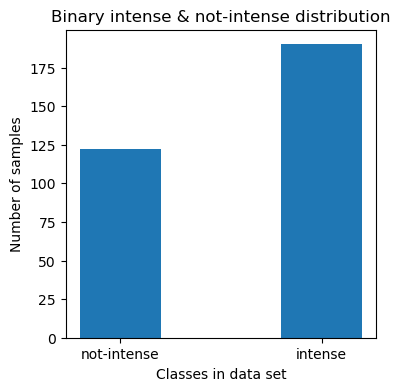

In [32]:
# plot how the intensity class is distributed in the data set
plt.subplots(figsize=(4, 4))
plt.bar(classes, counts, width=0.4, tick_label = ['not-intense', 'intense'],)
plt.title('Binary intense & not-intense distribution')
plt.xlabel('Classes in data set')
plt.ylabel('Number of samples')
plt.show()

In [33]:
dragon_df = get_dragon_df()
dragon_df.head()

,CID,MW,AMW,Sv,Se,Sp,Si,Mv,Me,Mp,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,126,122.130000,8.142,10.010,15.3050,10.193000,16.664000,0.667,1.020,0.680,...,66.806000,113.420000,0.864,-2.37,-2.42,-2.39,1.0,40.0,0.0,0
1,176,60.060000,7.507,4.483,8.4220,4.896675,9.249000,0.560,1.053,0.554,...,36.165462,58.100000,0.684,-1.06,-0.95,-0.84,0.0,12.0,0.0,0
2,177,57.375125,6.294,4.483,7.7353,4.896675,8.566025,0.538,1.013,0.568,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.0,0
3,179,88.120000,6.294,7.537,14.1890,7.955000,16.080000,0.538,1.014,0.568,...,54.205000,92.700000,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.0,0
4,180,58.090000,5.809,5.295,9.9780,5.739000,11.455000,0.530,0.998,0.574,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,12.0,0.0,0


In [34]:
dragon_df.shape

(4065, 2491)

In [35]:
waka_dragon_merged_df = pd.merge(
    waka_df,
    dragon_df,
    how='left',
    left_on='CID',
    right_on='CID'
)

In [39]:
waka_dragon_merged_df.sort_values(by='CID', inplace=True)

In [40]:
waka_dragon_merged_df.head(10)

,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,AMW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,6.294,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,7.581,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,6.759,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,8.597,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,6.444,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0
250,251,454,124-13-0,octanal,78.17,1.33,1.13,1,128.24,5.130,...,88.578,153.11,0.835,-3.97,-4.21,-4.27,0.0,30.0,0.025,0.0
182,182,798,120-72-9,indole,43.59,-0.19,0.54,1,117.16,7.323,...,67.807,100.88,1.022,-2.95,-3.06,-3.06,3.0,46.0,0.000,0.0
251,252,957,111-87-5,octanol,40.11,0.60,0.51,1,130.26,4.824,...,91.505,155.75,0.806,-4.10,-4.35,-4.42,0.0,30.0,0.023,0.0
310,312,1183,121-33-5,vanillin,39.02,-1.81,0.00,1,152.16,8.008,...,80.395,139.51,0.853,-2.17,-2.20,-2.15,1.0,50.0,0.000,0.0
43,43,2345,120-51-4,benzyl benzoate,13.25,-2.37,0.16,0,212.26,7.581,...,117.777,203.34,0.961,-4.38,-4.66,-4.74,2.0,76.0,0.023,0.0


In [41]:
waka_dragon_merged_df.to_csv('data/waka_dragon_merged.csv')

In [42]:
#starting the constaraction of feture matrix
numSamples = waka_dragon_merged_df.shape[0]
mX = np.zeros(shape = (numSamples, 10))

In [ ]:
features_list = ['MW', 'MLOGP']
mX[:, [0, 1]] = waka_dragon_merged_df[features_list].values

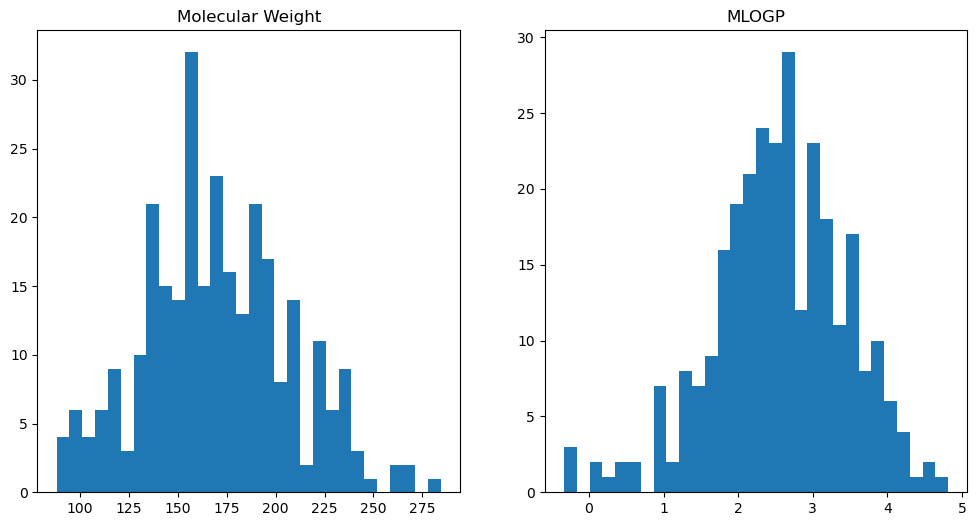

In [47]:
hF, hA = plt.subplots(nrows=1, ncols=2, figsize = (12, 6))

hA[0].hist(mX[:, 0], bins = 30)
hA[0].set_title('Molecular Weight')

hA[1].hist(mX[:, 1], bins = 30)
hA[1].set_title('MLOGP')

plt.show()